# HVAC Electircity Demand Analysis and Prediction

## Feature Creation and lag features


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor

np.random.seed(42)

In [50]:
df = pd.read_csv("./data/Load_data_01.csv")
df["Time"] = pd.to_datetime(df["Time"])
df.set_index("Time", inplace=True)

In [51]:
df_daily_rec = pd.read_csv("./data/df_daily_feature_creation.csv")
df_daily_rec["Time"] = pd.to_datetime(df_daily_rec["Time"])
df_daily_rec.set_index("Time", inplace=True)

In [52]:
df_daily = df_daily_rec

In [53]:
df_daily

,electricity_demand_values,air_pressure,solar_irridiation_positive,total_cloud_cover_percent,wind_speed_range,Wind scale 2,Wind scale 3,huimidity_Comfort,huimidity_Uncomfortable Dry,huimidity_Uncomfortable Wet,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
Time,,,,,,,,,,,,,,,,,,,,,
2010-12-01,8549.852211,732.041667,492.615385,0.218750,5.0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2010-12-02,7910.870398,729.583333,502.000000,0.145833,11.0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2010-12-03,8758.895028,732.687500,441.769231,0.187500,10.0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2010-12-04,10013.066990,734.087500,501.769231,0.291667,9.0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2010-12-05,10694.276861,736.916667,481.384615,0.062500,14.0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-11-24,11178.246191,734.166667,435.076923,0.083333,6.0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,1,0
2018-11-25,12096.578195,733.570833,512.769231,0.239583,13.0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
2018-11-26,11658.178583,733.987500,477.230769,0.322917,6.0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [54]:
df_daily.describe().T

,count,mean,std,min,25%,50%,75%,max
electricity_demand_values,2920.0,9453.465406,3230.948896,5106.015997,6836.863624,8863.772704,11172.705523,25405.855701
air_pressure,2920.0,734.587334,3.206897,724.691667,732.450000,734.291667,736.489583,747.420833
solar_irridiation_positive,2920.0,475.002634,31.305920,371.615385,452.961538,475.230769,496.307692,582.538462
total_cloud_cover_percent,2920.0,0.323900,0.178468,0.000000,0.191120,0.302083,0.427083,0.979167
wind_speed_range,2920.0,9.105479,2.406420,3.000000,7.000000,9.000000,10.000000,26.000000
Wind scale 2,2920.0,0.567123,0.495559,0.000000,0.000000,1.000000,1.000000,1.000000
Wind scale 3,2920.0,0.432877,0.495559,0.000000,0.000000,0.000000,1.000000,1.000000
huimidity_Comfort,2920.0,0.460959,0.498559,0.000000,0.000000,0.000000,1.000000,1.000000
huimidity_Uncomfortable Dry,2920.0,0.002740,0.052280,0.000000,0.000000,0.000000,0.000000,1.000000
huimidity_Uncomfortable Wet,2920.0,0.536301,0.498766,0.000000,0.000000,1.000000,1.000000,1.000000


## Sliding window method for electricity demand and heating demand


### Add lag features for electricity demand and heating demand (sliding window method)

- Average electricity demand in the past few days
- Average heating demand standard deviation in the past few days
- Electricity demand per day in the past few days


In [55]:
df_daily["heat_demand_values"] = df["heat_demand_values"].resample("D").sum()

In [56]:
window_sizes = [7,14]  # Define the window sizes
for window_size in window_sizes:
    # Calculate the rolling mean and standard deviation for the specified window size
    df_daily[f"electricity_demand_{window_size}d_mean"] = (
        df_daily["electricity_demand_values"].rolling(window=window_size).mean()
    )
    df_daily[f"electricity_demand_{window_size}d_std"] = (
        df_daily["electricity_demand_values"].rolling(window=window_size).std()
    )

    df_daily[f"heat_demand_{window_size}d_mean"] = (
        df_daily["heat_demand_values"].rolling(window=window_size).mean()
    )
    df_daily[f"heat_demand_{window_size}d_std"] = (
        df_daily["heat_demand_values"].rolling(window=window_size).std()
    )

lag_days = [1,6,13]  # Define the window sizes for lag features

for lag in lag_days:
    df_daily[f"electricity_demand_lag_{lag}"] = df_daily[
        "electricity_demand_values"
    ].shift(lag)

In [57]:
df_daily.dropna(inplace=True)

In [58]:
df_daily

,electricity_demand_values,air_pressure,solar_irridiation_positive,total_cloud_cover_percent,wind_speed_range,Wind scale 2,Wind scale 3,huimidity_Comfort,huimidity_Uncomfortable Dry,huimidity_Uncomfortable Wet,...,electricity_demand_7d_std,heat_demand_7d_mean,heat_demand_7d_std,electricity_demand_14d_mean,electricity_demand_14d_std,heat_demand_14d_mean,heat_demand_14d_std,electricity_demand_lag_1,electricity_demand_lag_6,electricity_demand_lag_13
Time,,,,,,,,,,,,,,,,,,,,,
2010-12-14,10497.548672,734.091667,482.538462,0.260417,10.0,1,0,0,0,1,...,732.330361,10934.848173,3091.497480,9317.717453,818.696830,10787.564023,3599.690447,9989.506677,9338.504217,8549.852211
2010-12-15,9372.873155,734.083333,429.846154,0.385417,11.0,0,1,0,0,1,...,732.333183,10955.838545,3087.536536,9376.504664,788.302973,11047.381768,3423.019757,10497.548672,8722.556863,7910.870398
2010-12-16,9642.006543,733.541667,512.153846,0.656250,10.0,1,0,0,0,1,...,679.996660,11539.577308,2886.771143,9500.157246,667.188619,11596.583798,2908.049958,9372.873155,8308.701420,8758.895028
2010-12-17,10833.626184,733.045833,518.923077,0.364583,9.0,0,1,0,0,1,...,616.153081,13138.895718,2720.027414,9648.352328,718.333182,12250.564395,3182.099101,9642.006543,9378.021443,10013.066990
2010-12-18,9970.866886,731.033333,520.769231,0.333333,9.0,1,0,0,0,1,...,580.186384,13509.199413,2595.255433,9645.338035,716.771873,12230.814356,3170.379664,10833.626184,9235.271623,10694.276861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-11-24,11178.246191,734.166667,435.076923,0.083333,6.0,0,1,1,0,0,...,649.925832,24094.169676,3784.653602,11747.372173,907.751832,22066.752174,4718.468105,12212.413580,11511.109391,10712.916186
2018-11-25,12096.578195,733.570833,512.769231,0.239583,13.0,1,0,1,0,0,...,615.465488,24461.171168,3456.002075,11846.205174,860.557433,22499.401158,4461.827440,11178.246191,12745.777979,11289.590300
2018-11-26,11658.178583,733.987500,477.230769,0.322917,6.0,1,0,0,0,1,...,549.966031,23476.689750,3347.443253,11872.532908,847.761670,22611.802338,4393.544986,12096.578195,11986.168236,9499.380779


## Training and Testing models


In [59]:
def train_test_set(df, start, end, split_time):
    train = df[(df.index > start) & (df.index <= split_time)]
    test = df[(df.index > split_time) & (df.index <= end)]
    X_train, y_train = (
        train.drop(["electricity_demand_values"], axis=1),
        train["electricity_demand_values"],
    )
    X_test, y_test = (
        test.drop(["electricity_demand_values"], axis=1),
        test["electricity_demand_values"],
    )
    return X_train, y_train, X_test, y_test

In [60]:
X_train, y_train, X_test, y_test = train_test_set(
    df_daily, "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((516, 45), (516,), (172, 45), (172,))

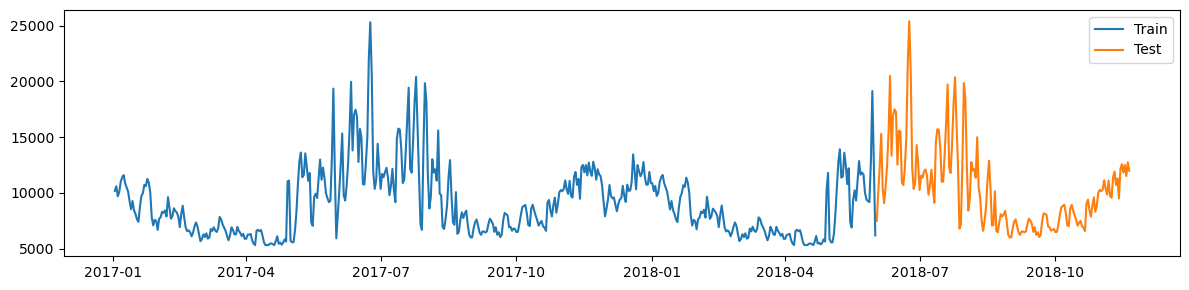

In [61]:
_, ax = plt.subplots(figsize=(12, 3))

ax.plot(y_train.index, y_train, label="Train")
ax.plot(y_test.index, y_test, label="Test")

plt.legend()
plt.tight_layout()

plt.show()

In [62]:
def MAPE(y_true, y_pred):  # Calculate Mean Absolute Percentage Error
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_index = y_true != 0
    y_true = y_true[non_zero_index]
    y_pred = y_pred[non_zero_index]
    if len(y_true) == 0:
        return np.nan
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # in percentage

In [63]:
def evaluate_model_performance(
    y_true, y_pred
):  # def the output function for model performance evaluation
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = np.mean(np.abs(y_test - y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)
    return round(rmse, 4), round(mae, 4), round(mape, 2), round(r2, 4)

In [119]:
def train_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse, mae, mape, r2 = evaluate_model_performance(y_test, y_pred)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.2f} %")
    print(f"R2: {r2:.4f}")
    df_performance = pd.DataFrame(
        {"RMSE": rmse, "MAE": mae, "MAPE(%)": mape, f"$R^2$": r2}, index=[0]
    )
    df_results = pd.DataFrame(
        {"Time": y_test.index, "y_test": y_test, "y_pred": y_pred}
    )
    return df_performance, df_results

In [65]:
def plot_results(df_results, model_name):
    _, ax = plt.subplots(figsize=(12, 3))
    ax.plot(df_results["Time"], df_results["y_test"], label="Test")
    ax.plot(df_results["Time"], df_results["y_pred"], label="Predicted")
    ax.set_title(model_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [66]:
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
df_performance, df_results = train_model(X_train, y_train, X_test, y_test, dt_reg)

RMSE: 2065.1127
MAE: 1011.4354
MAPE: 8.32 %
R2: 0.6855


In [67]:
df_performance

,RMSE,MAE,MAPE(%),$R^2$
0,2065.1127,1011.4354,8.32,0.6855


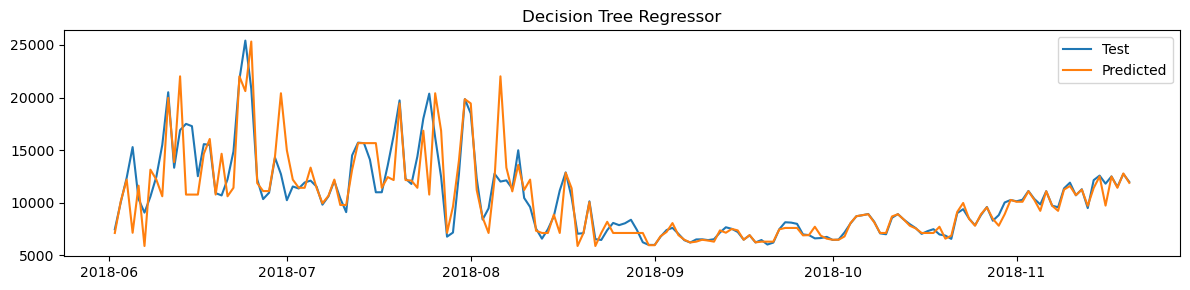

In [68]:
plot_results(df_results, "Decision Tree Regressor")

In [69]:
RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

df_performance, df_results = train_model(X_train, y_train, X_test, y_test, RF_reg)

RMSE: 1360.1623
MAE: 841.7257
MAPE: 7.26 %
R2: 0.8636


In [70]:
df_performance

,RMSE,MAE,MAPE(%),$R^2$
0,1360.1623,841.7257,7.26,0.8636


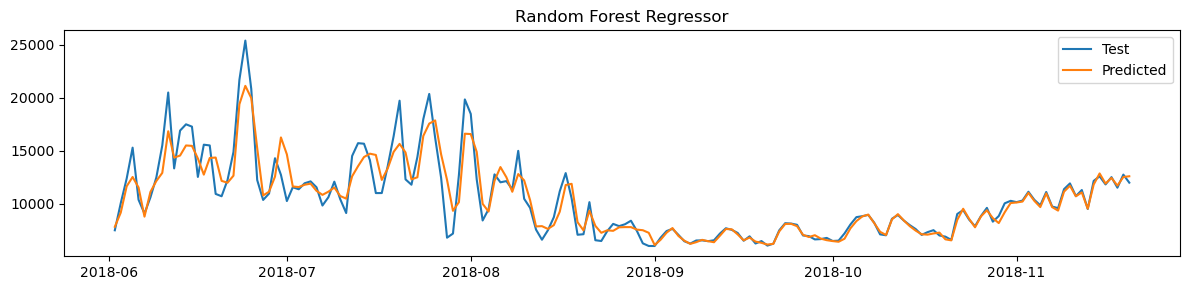

In [71]:
plot_results(df_results, "Random Forest Regressor")

In [72]:
ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=100,
    random_state=42,
)

df_performance, df_results = train_model(X_train, y_train, X_test, y_test, ada_reg)

RMSE: 1084.3813
MAE: 579.1127
MAPE: 5.12 %
R2: 0.9133


In [73]:
df_performance

,RMSE,MAE,MAPE(%),$R^2$
0,1084.3813,579.1127,5.12,0.9133


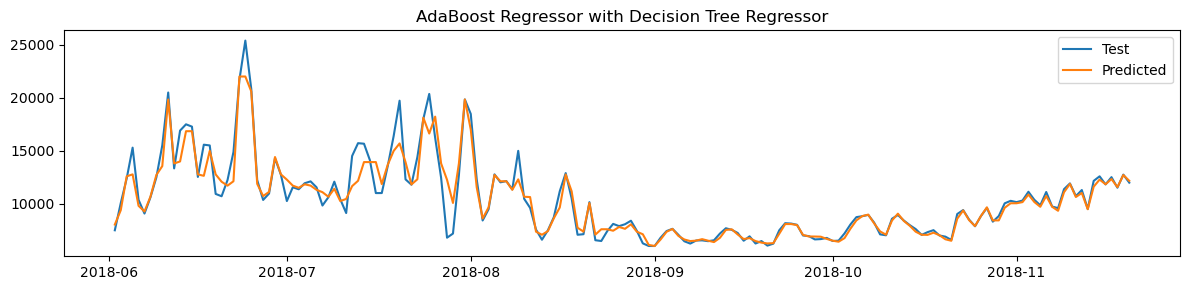

In [74]:
plot_results(df_results, "AdaBoost Regressor with Decision Tree Regressor")

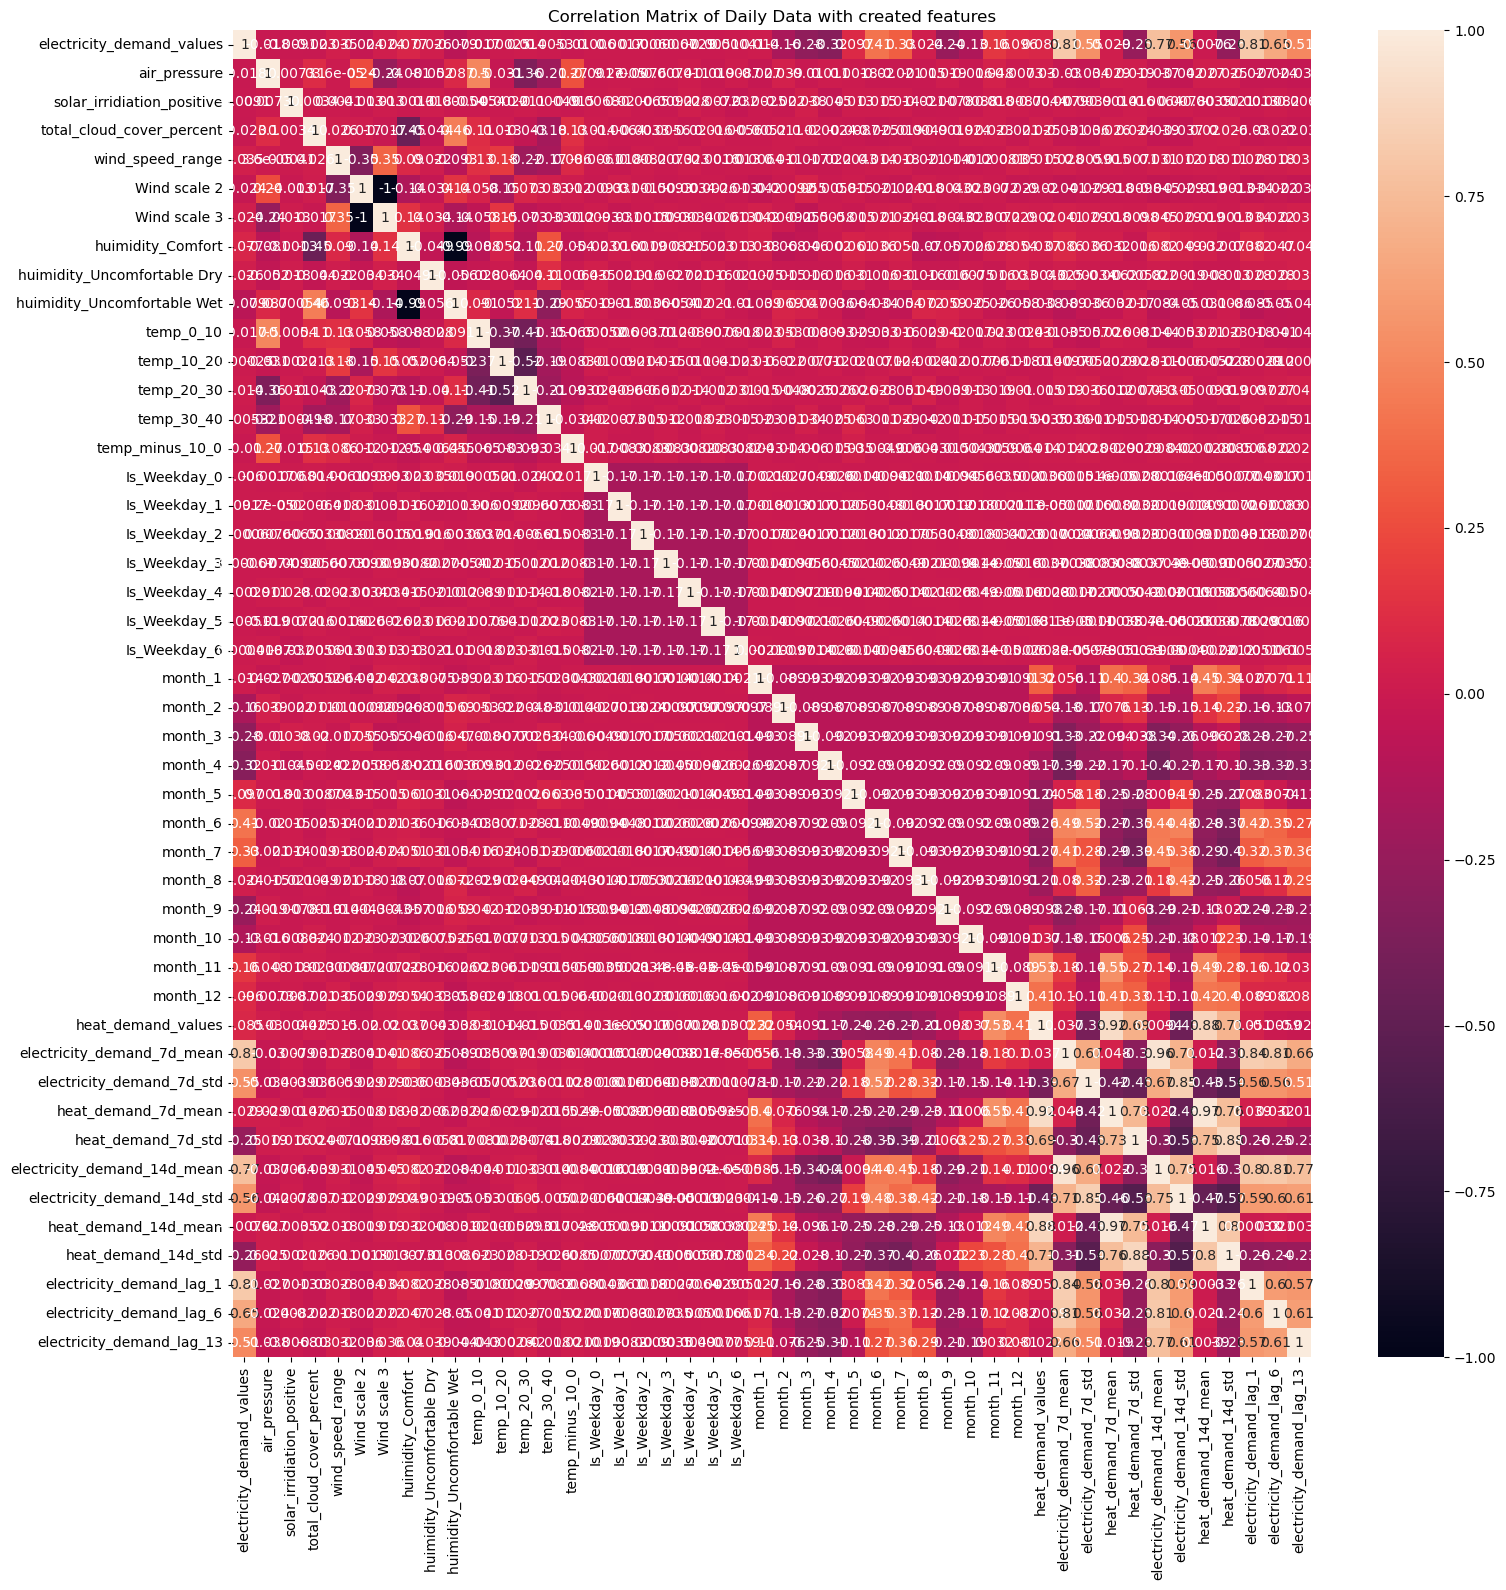

In [75]:
_, ax = plt.subplots(figsize=(16, 16))
sns.heatmap(df_daily.corr(), annot=True, ax=ax)
ax.set_title("Correlation Matrix of Daily Data with created features")
plt.tight_layout()
plt.show()

## Features selection


### Remove meterological features


In [76]:
df_daily.drop(
    columns=[
        "air_pressure",
        "solar_irridiation_positive",
        "total_cloud_cover_percent",
        "wind_speed_range",
        "Wind scale 2",
        "Wind scale 3",
        "huimidity_Comfort",
        "huimidity_Uncomfortable Dry",
        "huimidity_Uncomfortable Wet",
        "temp_0_10",
        "temp_10_20",
        "temp_20_30",
        "temp_30_40",
        "temp_minus_10_0",
    ],
    inplace=True,
)

In [77]:
X_train, y_train, X_test, y_test = train_test_set(
    df_daily, "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((516, 31), (516,), (172, 31), (172,))

In [78]:
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
RF_reg = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)
ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=100,
    random_state=42,
)

In [79]:
reg_ls = [dt_reg, RF_reg, ada_reg]
reg_ls_name = ["Decision Tree", "Random Forest", "AdaBoost"]


def model_evaluation(reg_ls, reg_ls_name, X_train, y_train, X_test, y_test):
    performance_results = {}
    for reg, reg_name in zip(reg_ls, reg_ls_name):
        df_performance = train_model(X_train, y_train, X_test, y_test, reg)[0]
        performance_results[reg_name] = df_performance

    performance_results_df = (
        pd.concat(performance_results, axis=0)
        .reset_index(level=0)
        .rename(columns={"level_0": "Model Name"})
    )

    return performance_results_df

In [80]:
performance_results_df = model_evaluation(
    reg_ls, reg_ls_name, X_train, y_train, X_test, y_test
)

RMSE: 1543.3290
MAE: 737.5078
MAPE: 6.37 %
R2: 0.8244
RMSE: 1157.1544
MAE: 716.6292
MAPE: 6.26 %
R2: 0.9013
RMSE: 632.8763
MAE: 338.0960
MAPE: 3.22 %
R2: 0.9705


In [81]:
performance_results_df

,Model Name,RMSE,MAE,MAPE(%),$R^2$
0,Decision Tree,1543.3290,737.5078,6.37,0.8244
0,Random Forest,1157.1544,716.6292,6.26,0.9013
0,AdaBoost,632.8763,338.0960,3.22,0.9705


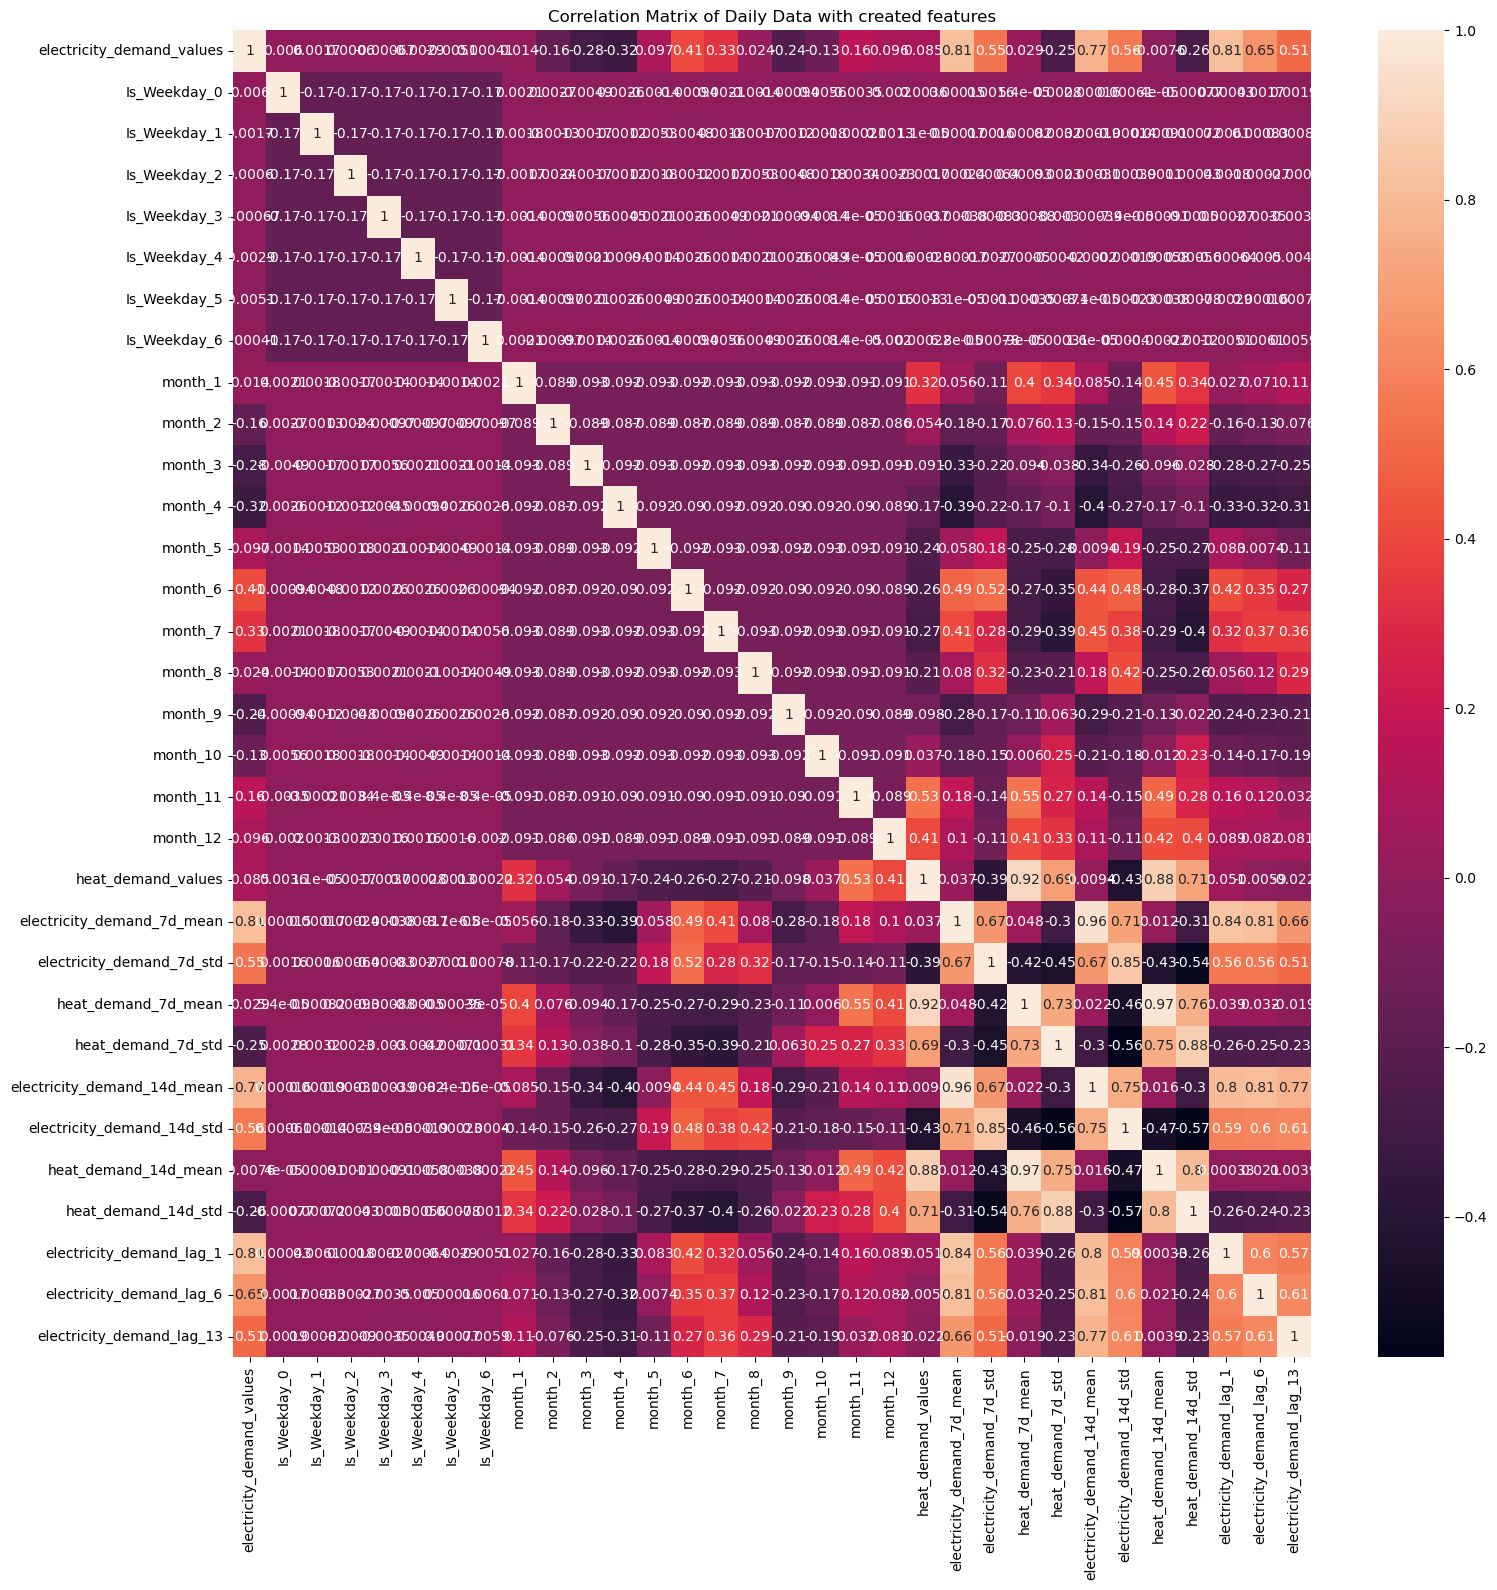

In [82]:
_, ax = plt.subplots(figsize=(16, 16))
sns.heatmap(df_daily.corr(), annot=True, ax=ax)
ax.set_title("Correlation Matrix of Daily Data with created features")
plt.tight_layout()
plt.show()

### Remove time features


In [83]:
df_daily.drop(
    columns=[
        "Is_Weekday_0",
        "Is_Weekday_1",
        "Is_Weekday_2",
        "Is_Weekday_3",
        "Is_Weekday_4",
        "Is_Weekday_5",
        "Is_Weekday_6",
        "month_1",
        "month_2",
        "month_3",
        "month_4",
        "month_5",
        "month_6",
        "month_7",
        "month_8",
        "month_9",
        "month_10",
        "month_11",
        "month_12",
    ],
    inplace=True,
)

In [84]:
X_train, y_train, X_test, y_test = train_test_set(
    df_daily, "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((516, 12), (516,), (172, 12), (172,))

In [85]:
performance_results_df = model_evaluation(
    reg_ls, reg_ls_name, X_train, y_train, X_test, y_test
)

RMSE: 1402.9167
MAE: 652.8788
MAPE: 5.77 %
R2: 0.8549
RMSE: 1081.1453
MAE: 681.1001
MAPE: 5.96 %
R2: 0.9138
RMSE: 390.3241
MAE: 227.5588
MAPE: 2.24 %
R2: 0.9888


In [86]:
performance_results_df

,Model Name,RMSE,MAE,MAPE(%),$R^2$
0,Decision Tree,1402.9167,652.8788,5.77,0.8549
0,Random Forest,1081.1453,681.1001,5.96,0.9138
0,AdaBoost,390.3241,227.5588,2.24,0.9888


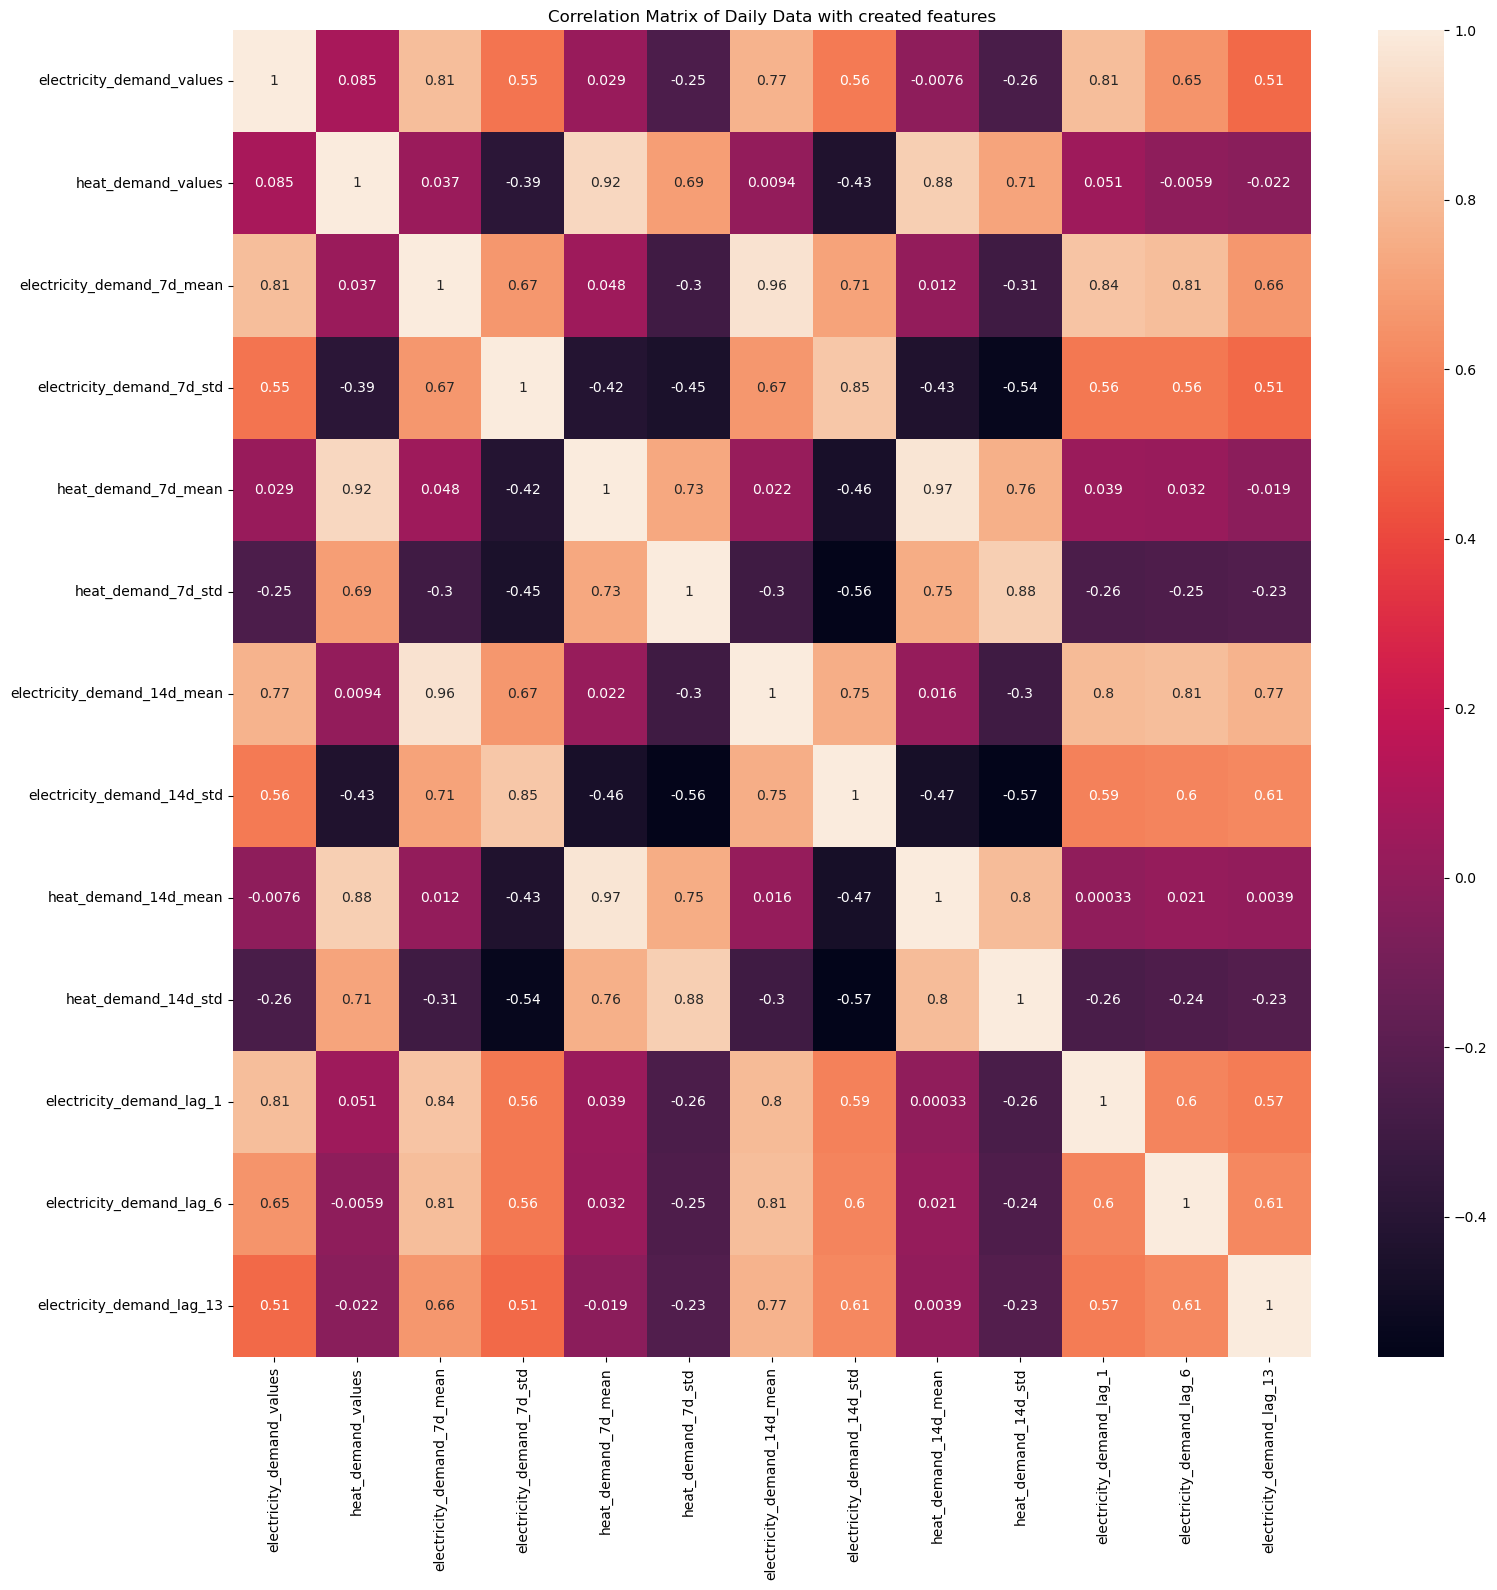

In [87]:
_, ax = plt.subplots(figsize=(16, 16))
sns.heatmap(df_daily.corr(), annot=True, ax=ax)
ax.set_title("Correlation Matrix of Daily Data with created features")
plt.tight_layout()
plt.show()

### Remove the rolling mean and standard deviation features

- Keep the lag features for electricity demand only


In [88]:
df_daily = df_daily_rec[["electricity_demand_values"]]

In [89]:
lag_days = [1,6,13]  # Define the window sizes for lag features

for lag in lag_days:
    df_daily[f"electricity_demand_lag_{lag}"] = df_daily[
        "electricity_demand_values"
    ].shift(lag)

df_daily.dropna(inplace=True)

/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_1832/1431306175.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily[f"electricity_demand_lag_{lag}"] = df_daily[
/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_1832/1431306175.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily[f"electricity_demand_lag_{lag}"] = df_daily[
/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_1832/1431306175.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

In [90]:
X_train, y_train, X_test, y_test = train_test_set(
    df_daily, "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((516, 3), (516,), (172, 3), (172,))

In [91]:
performance_results_df = model_evaluation(
    reg_ls, reg_ls_name, X_train, y_train, X_test, y_test
)

RMSE: 1917.1661
MAE: 1087.3262
MAPE: 9.91 %
R2: 0.7290
RMSE: 1462.7784
MAE: 1044.1347
MAPE: 9.62 %
R2: 0.8422
RMSE: 1203.3016
MAE: 748.6197
MAPE: 7.39 %
R2: 0.8932


In [92]:
performance_results_df

,Model Name,RMSE,MAE,MAPE(%),$R^2$
0,Decision Tree,1917.1661,1087.3262,9.91,0.7290
0,Random Forest,1462.7784,1044.1347,9.62,0.8422
0,AdaBoost,1203.3016,748.6197,7.39,0.8932


### Remove the lag features for electricity demand, keep rolling mean and standard deviation features


In [93]:
df_daily = df_daily_rec[["electricity_demand_values"]]

In [94]:
window_sizes = [7, 14]  # Define the window sizes
for window_size in window_sizes:
    # Calculate the rolling mean and standard deviation for the specified window size
    df_daily[f"electricity_demand_{window_size}d_mean"] = (
        df["electricity_demand_values"].rolling(window=window_size).mean()
    )
    df_daily[f"electricity_demand_{window_size}d_std"] = (
        df["electricity_demand_values"].rolling(window=window_size).std()
    )

    df_daily[f"heat_demand_{window_size}d_mean"] = (
        df["heat_demand_values"].rolling(window=window_size).mean()
    )
    df_daily[f"heat_demand_{window_size}d_std"] = (
        df["heat_demand_values"].rolling(window=window_size).std()
    )

df_daily.dropna(inplace=True)

/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_1832/2285049393.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily[f"electricity_demand_{window_size}d_mean"] = (
/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_1832/2285049393.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily[f"electricity_demand_{window_size}d_std"] = (
/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_1832/2285049393.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of

In [95]:
X_train, y_train, X_test, y_test = train_test_set(
    df_daily, "2017-01-01", "2018-11-20", "2018-06-01"
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((516, 8), (516,), (172, 8), (172,))

In [96]:
performance_results_df = model_evaluation(
    reg_ls, reg_ls_name, X_train, y_train, X_test, y_test
)

RMSE: 2530.5696
MAE: 1554.4377
MAPE: 13.52 %
R2: 0.5278
RMSE: 1796.4697
MAE: 1134.0026
MAPE: 9.86 %
R2: 0.7620
RMSE: 2108.6816
MAE: 1240.3549
MAPE: 10.46 %
R2: 0.6721


In [97]:
performance_results_df

,Model Name,RMSE,MAE,MAPE(%),$R^2$
0,Decision Tree,2530.5696,1554.4377,13.52,0.5278
0,Random Forest,1796.4697,1134.0026,9.86,0.7620
0,AdaBoost,2108.6816,1240.3549,10.46,0.6721


- Performance is worse than the model with lag features for electricity demand


### Add more electricity demand lag features

- The feature selection result indicates electricity demand lag features' importace to the model's predictive capacity. Consider the electricity demand seasonality, we will examine the model's performance with more electricity demand lag features next.


In [98]:
df_daily = df_daily_rec[["electricity_demand_values"]]

In [99]:
lag_days = np.arange(1, 61, 1)

for lag in lag_days:
    df_daily[f"electricity_demand_lag_{lag}"] = df_daily[
        "electricity_demand_values"
    ].shift(lag)

/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_1832/3269318358.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily[f"electricity_demand_lag_{lag}"] = df_daily[
/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_1832/3269318358.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily[f"electricity_demand_lag_{lag}"] = df_daily[
/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_1832/3269318358.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

In [100]:
df_daily.dropna(inplace=True)

In [101]:
def corr_features_plot(df_daily, threshold):
    correlations = df_daily.corr()["electricity_demand_values"]
    correlated_features = correlations[abs(correlations) > threshold].index
    _, ax = plt.subplots(figsize=(16, 16))
    sns.heatmap(
        df_daily.corr().loc[correlated_features, correlated_features], annot=True, ax=ax
    )
    ax.set_title(f"Correlation Matrix of Daily Data (abs(corr) >= {threshold})")
    plt.tight_layout()
    plt.show()

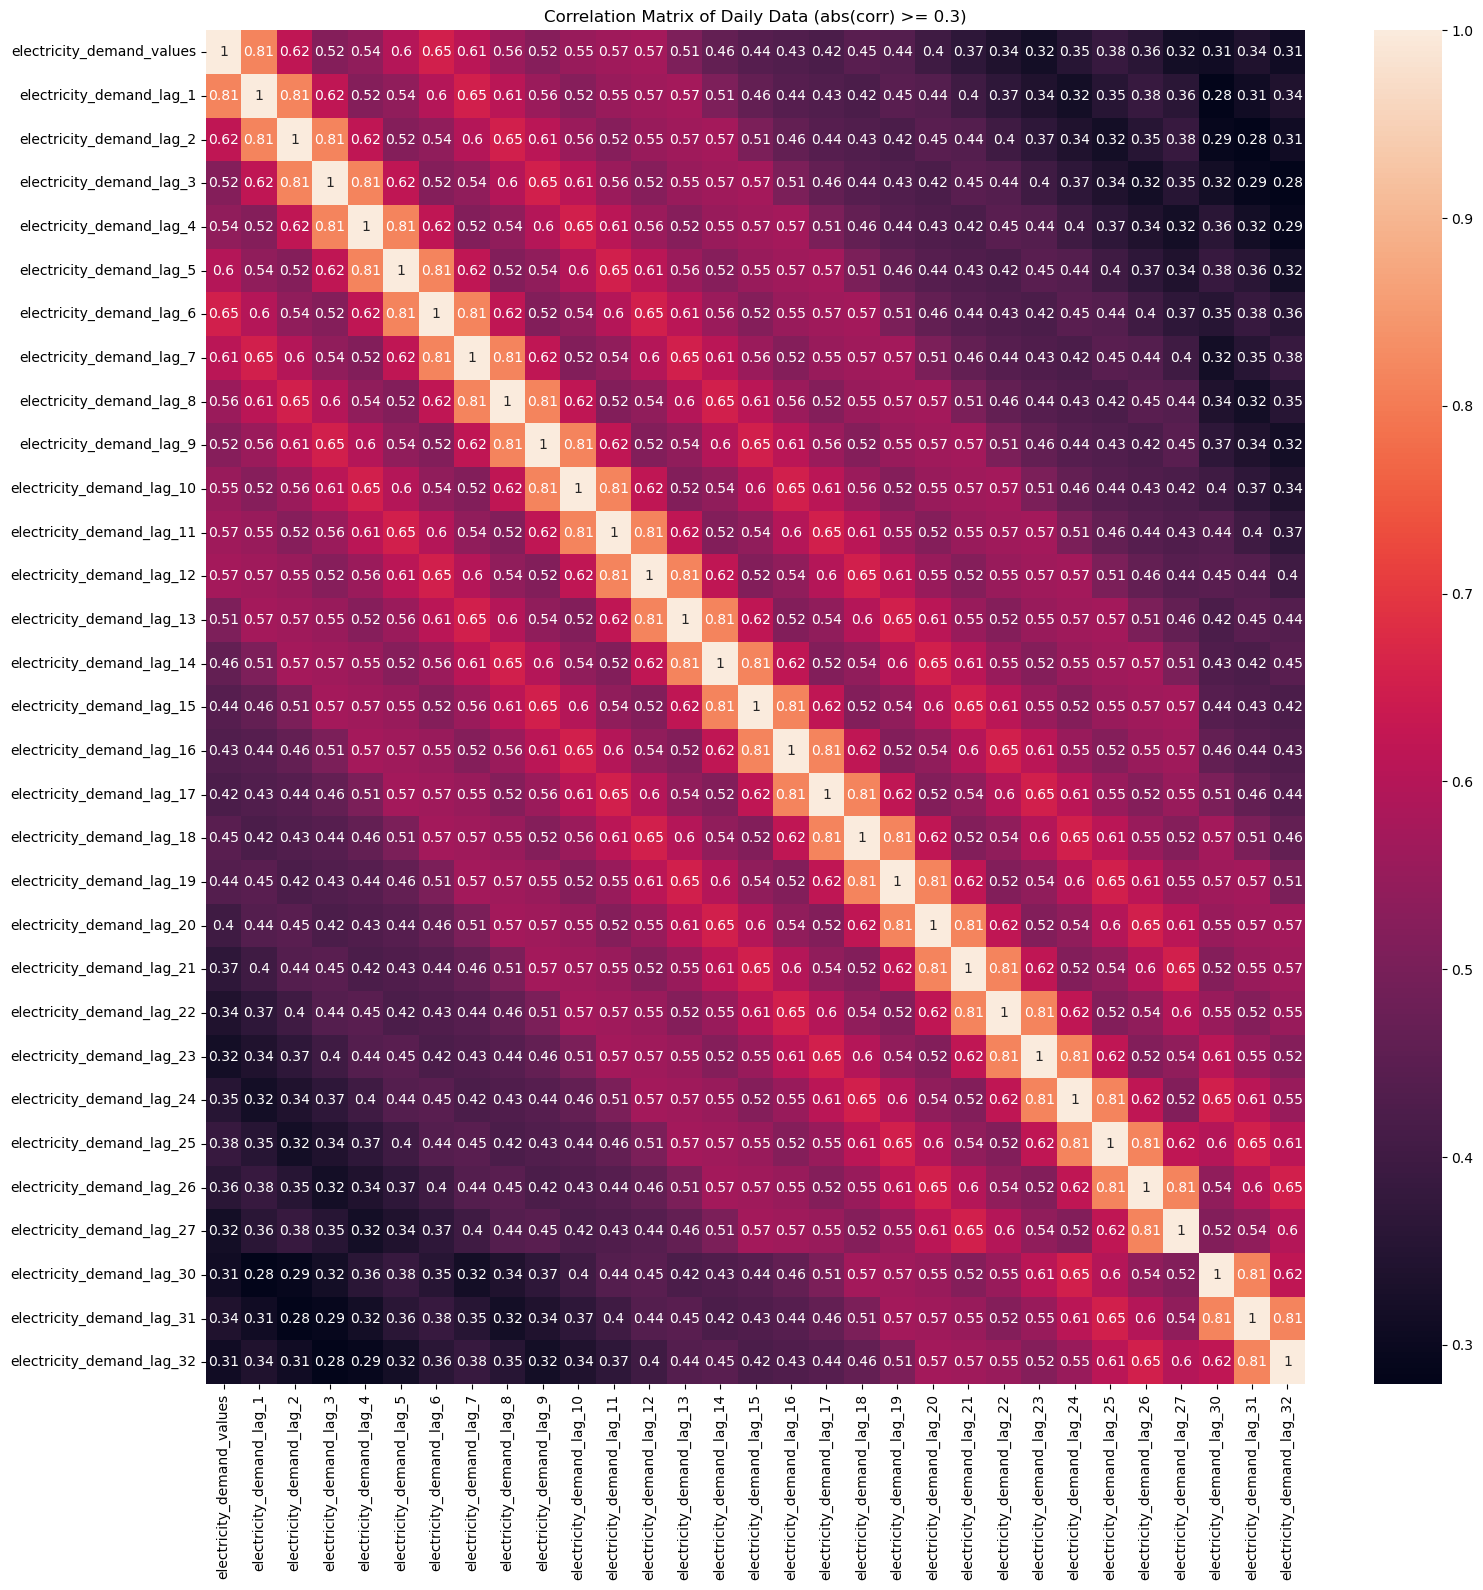

In [102]:
corr_features_plot(df_daily, 0.3)

### Find the relationship between the correlation coefficient and the model's performance


In [103]:
mape_scorer = make_scorer(
    MAPE, greater_is_better=False
)  # define mean absolute percentage scorer

In [104]:
# Define a function to calculate RMSE, MAE, and R-squared scores based on a correlation threshold
def correlation_threshold_train(df_daily, threshold, model_name, regressor, split=5):
    # Calculate correlations with electricity_demand_values and select highly correlated features
    correlations = df_daily.corr()["electricity_demand_values"]
    correlated_features = correlations[abs(correlations) > threshold].index

    # Split the dataset into training and testing sets
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        df_daily[correlated_features].drop("electricity_demand_values", axis=1),
        df_daily[correlated_features]["electricity_demand_values"],
        test_size=0.2,
        random_state=42,
    )

    # Create a KFold cross-validation object
    kf = KFold(n_splits=split, shuffle=True, random_state=42)

    # Calculate negative mean squared error scores using cross-validation
    mse_scores = -cross_val_score(
        regressor, X_trainval, y_trainval, cv=kf, scoring="neg_mean_squared_error"
    )

    # Calculate negative mean absolute error scores using cross-validation
    mae_scores = -cross_val_score(
        regressor, X_trainval, y_trainval, cv=kf, scoring="neg_mean_absolute_error"
    )
    # Calculate mean absolute percentage error scores using cross-validation
    mape_scores = -cross_val_score(
        regressor, X_trainval, y_trainval, cv=kf, scoring=mape_scorer
    )

    # Calculate R-squared scores using cross-validation
    r2_scores = cross_val_score(regressor, X_trainval, y_trainval, cv=kf, scoring="r2")

    # Calculate the mean RMSE, MAE, and R-squared scores
    rmse_scores = np.sqrt(mse_scores)
    mean_rmse = round(rmse_scores.mean(), 4)
    mean_mae = round(mae_scores.mean(), 4)
    mean_mape = round(mape_scores.mean(), 4)
    mean_r2 = round(r2_scores.mean(), 4)

    # Create a dictionary to store the results
    res_dict = {
        "Model name": model_name,
        "corr_threshold": threshold,
        "Fold": split,
        "AVG RMSE": mean_rmse,
        "AVG MAE": mean_mae,
        "AVG MAPE (%)": mean_mape,
        "AVG R2": mean_r2,
    }

    # Return the results dictionary
    return res_dict

In [105]:
ada_reg = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=100,
    random_state=42,
)

In [106]:
thresholds = [0, 0.1, 0.3, 0.5, 0.6, 0.7, 0.8]

results_ls = [
    correlation_threshold_train(df_daily, _, "AdaBoost", ada_reg, 5) for _ in thresholds
]

df_results = pd.DataFrame(results_ls)

In [107]:
df_results

,Model name,corr_threshold,Fold,AVG RMSE,AVG MAE,AVG MAPE (%),AVG R2
0,AdaBoost,0.0,5,379.5737,213.9064,2.3451,0.9851
1,AdaBoost,0.1,5,392.4277,218.6191,2.4132,0.9841
2,AdaBoost,0.3,5,432.8184,237.9778,2.6413,0.9814
3,AdaBoost,0.5,5,531.0593,303.3116,3.3445,0.9724
4,AdaBoost,0.6,5,844.4903,484.0533,5.2748,0.9318
5,AdaBoost,0.7,5,2203.8130,1350.5392,13.8849,0.5273
6,AdaBoost,0.8,5,2203.8130,1350.5392,13.8849,0.5273


### Select features based on the correlation threshold 0.3


In [108]:
correlations = df_daily.corr()["electricity_demand_values"]
correlated_features = correlations[abs(correlations) > 0.3].index

In [109]:
 X_trainval, X_test, y_trainval, y_test = train_test_split(
        df_daily[correlated_features].drop("electricity_demand_values", axis=1),
        df_daily[correlated_features]["electricity_demand_values"],
        test_size=0.2,
        random_state=42,
    )

In [110]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_ls = []
mae_ls = []
rmse_ls = []
mape_ls = []

print(
    "AdaBoost Regressor with Decision Tree Regressor 5 Fold Cross Validation Results:\n"
)
for train_index, val_index in kf.split(X_trainval):
    X_train, X_val = (
        X_trainval.iloc[train_index],
        X_trainval.iloc[val_index],
    )
    y_train, y_val = (
        y_trainval.iloc[train_index],
        y_trainval.iloc[val_index],
    )
    ada_reg.fit(X_train, y_train)
    y_val_pred = ada_reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    mae = np.mean(np.abs(y_val_pred - y_val))
    mape = MAPE(y_val, y_val_pred)
    rmse_ls.append(rmse)
    r2_ls.append(r2)
    mape_ls.append(mape)
    mae_ls.append(mae)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.2f} %")
    print(f"R^2 Score: {r2:.4f}")

evaluation_df = pd.DataFrame(
    {
        "AVG RMSE": np.mean(rmse_ls),
        "AVG MAE": np.mean(mae_ls),
        "AVG MAPE(%)": np.mean(mape_ls),
        "AVG R2": np.mean(r2_ls),
    },
    index=[0],
)

AdaBoost Regressor with Decision Tree Regressor 5 Fold Cross Validation Results:

RMSE: 387.6069
MAE: 232.2746
MAPE: 2.65 %
R^2 Score: 0.9850
RMSE: 535.0399
MAE: 260.9541
MAPE: 2.78 %
R^2 Score: 0.9745
RMSE: 334.2099
MAE: 222.1333
MAPE: 2.54 %
R^2 Score: 0.9876
RMSE: 355.8629
MAE: 215.2630
MAPE: 2.35 %
R^2 Score: 0.9893
RMSE: 551.3726
MAE: 259.2638
MAPE: 2.89 %
R^2 Score: 0.9703


In [111]:
evaluation_df

,AVG RMSE,AVG MAE,AVG MAPE(%),AVG R2
0,432.818432,237.977753,2.641265,0.981351


In [112]:
y_pred = ada_reg.predict(X_test)

In [113]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Calculating RMSE
mae = np.mean(np.abs(y_pred - y_test))  # Calculating MAE
r2 = r2_score(y_test, y_pred)  # Calculating R2 score
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Calculating MAPE
print(
    f"Training on test set: RMSE: {rmse:.4f},MAE: {mae:.4f},MAPE:{mape:.4f} %, R2: {r2:.4f}"
)

df_results = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})

Training on test set: RMSE: 478.0339,MAE: 246.4705,MAPE:2.5747 %, R2: 0.9798


<Axes: xlabel='Time'>

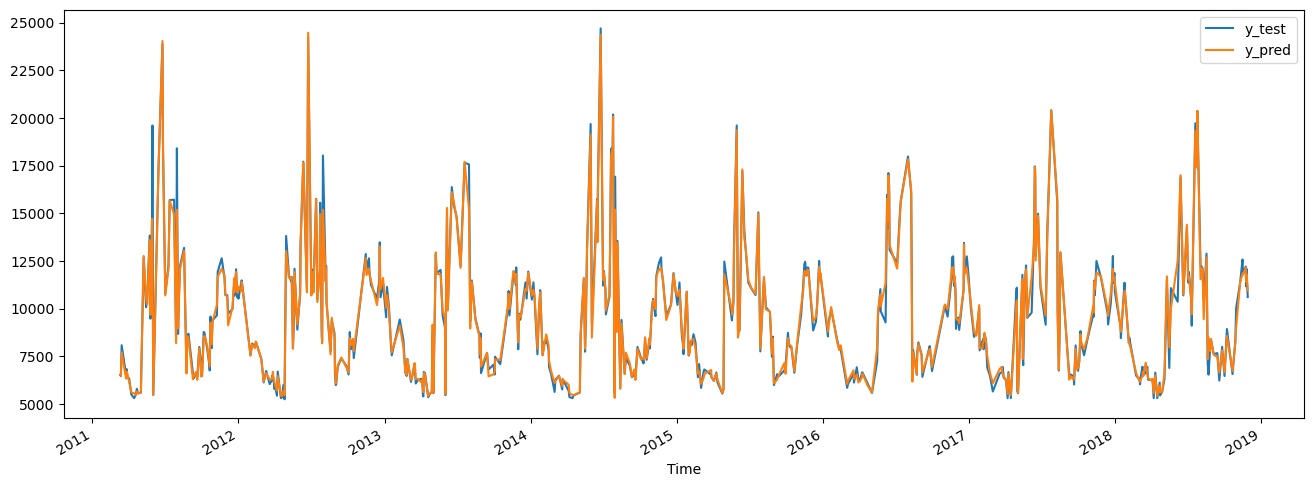

In [114]:
df_results.plot(figsize=(16, 6))

In [115]:
len(df_results)

570

In [116]:
test_idx = df_results.index.sort_values()[310:340]

<Axes: xlabel='Time'>

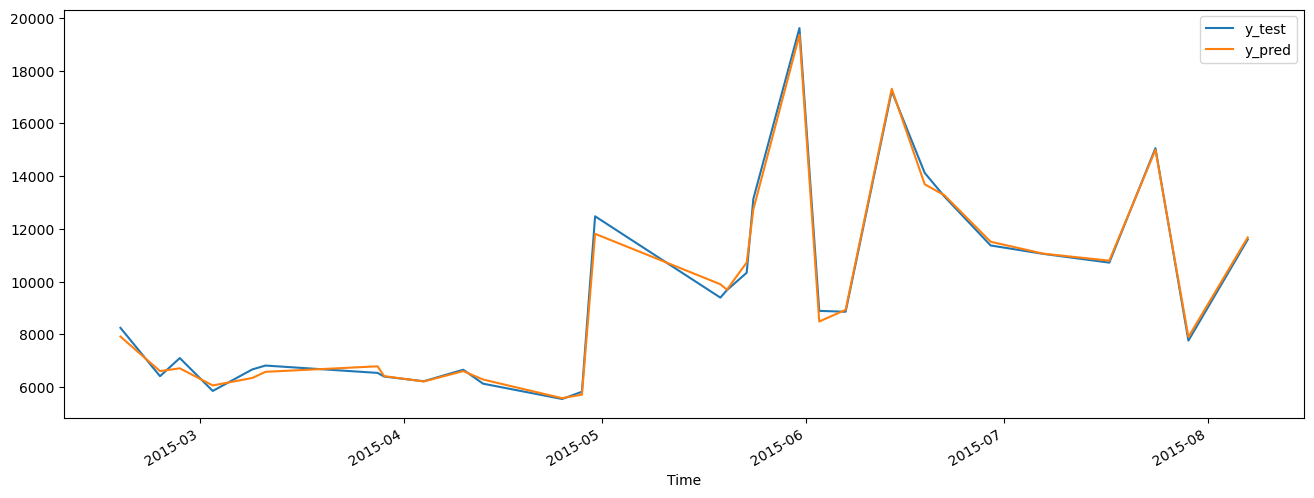

In [117]:
df_results.loc[test_idx].plot(figsize=(16, 6))

In [118]:
# df_daily.to_csv("./data/df_daily_feature_lags.csv")

## Conclusion

- Lag features helped the model to predict electricity demand and heating demand better on all evaluation metrics.
- By correlation coefficient matrix, we can find the relationships between present electricity demand and the number of previous days’ demand. With high correlated lag features, the model can predict the future demand with high accuracy as mentioned above.

